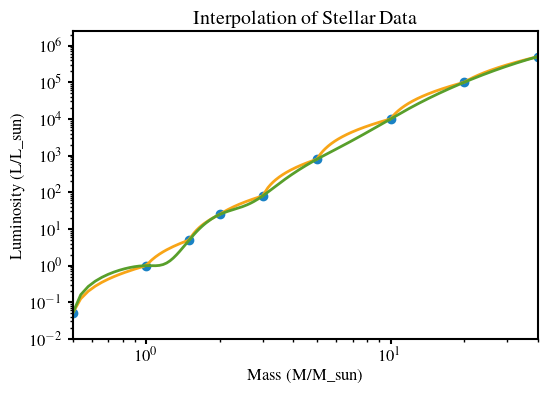

In [ ]:
# import required libraries
import matplotlib.pyplot as plt
import maxpy
import numpy as np

# data from the table
M = np.array([0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 10.0, 20.0, 40.0])
tau = np.array([56000, 10000, 3000, 1300, 400, 100, 20, 5, 3])
L = np.array([0.05, 1.0, 5.0, 25.0, 80.0, 800.0, 10000, 100000, 500000])
R = np.array([0.50, 1.00, 1.50, 2.00, 3.00, 4.00, 6.00, 10.0, 15.0])
T_eff = np.array([3800, 5800, 7200, 9000, 12000, 17000, 25000, 35000, 45000])
# dense grid for interpolation
x_dense = np.linspace(M.min(), M.max(), 1000)


# linear interpolation
def linear_interp_vec(x_data, y_data, x):
    i = np.searchsorted(x_data, x) - 1
    i = np.clip(i, 0, len(x_data) - 2)
    x0 = x_data[i]
    x1 = x_data[i + 1]
    y0 = y_data[i]
    y1 = y_data[i + 1]
    return y0 + (y1 - y0) * (x - x0) / (x1 - x0)


y_linear = linear_interp_vec(M, L, x_dense)


# cubic spline using linalg
def cubic_spline_coeffs_linalg(x, y):
    n = len(x) - 1
    h = np.diff(x)

    rhs = np.zeros(n + 1)
    rhs[1:n] = (3 / h[1:]) * (y[2:] - y[1:-1]) - (3 / h[:-1]) * (y[1:-1] - y[:-2])

    A = np.zeros((n + 1, n + 1))
    A[0, 0] = 1
    A[n, n] = 1

    i = np.arange(1, n)
    A[i, i - 1] = h[:-1]
    A[i, i] = 2 * (h[:-1] + h[1:])
    A[i, i + 1] = h[1:]

    c = np.linalg.solve(A, rhs)

    b = (y[1:] - y[:-1]) / h - h * (2 * c[:-1] + c[1:]) / 3
    d = (c[1:] - c[:-1]) / (3 * h)
    a = y[:-1]

    return a, b, c[:-1], d


def spline_eval_vec(x_data, coeffs, x):
    a, b, c, d = coeffs
    i = np.searchsorted(x_data, x) - 1
    i = np.clip(i, 0, len(a) - 1)
    dx = x - x_data[i]
    return a[i] + b[i] * dx + c[i] * dx**2 + d[i] * dx**3


coeffs = cubic_spline_coeffs_linalg(M, L)
y_spline = spline_eval_vec(M, coeffs, x_dense)

# plot
plt.figure()
plt.loglog(M, L, "o")  # original points
plt.loglog(x_dense, y_linear)  # linear interpolation
plt.loglog(x_dense, y_spline)  # cubic spline
plt.xlabel("Mass (M/M_sun)")
plt.ylabel("Luminosity (L/L_sun)")
plt.title("Interpolation of Stellar Data")
plt.show()

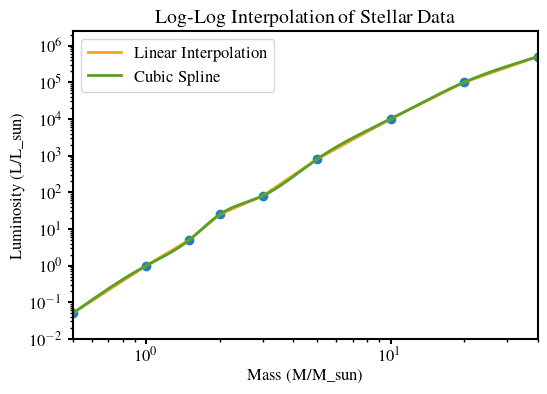

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# log-transform
logM = np.log10(M)
logL = np.log10(L)

x_dense_log = np.linspace(logM.min(), logM.max(), 500)


def linear_interp_vec(x_data, y_data, x):
    i = np.searchsorted(x_data, x) - 1
    i = np.clip(i, 0, len(x_data) - 2)
    x0 = x_data[i]
    x1 = x_data[i + 1]
    y0 = y_data[i]
    y1 = y_data[i + 1]
    return y0 + (y1 - y0) * (x - x0) / (x1 - x0)


def cubic_spline_coeffs_linalg(x, y):
    n = len(x) - 1
    h = np.diff(x)

    rhs = np.zeros(n + 1)
    rhs[1:n] = (3 / h[1:]) * (y[2:] - y[1:-1]) - (3 / h[:-1]) * (y[1:-1] - y[:-2])

    A = np.zeros((n + 1, n + 1))
    A[0, 0] = 1
    A[n, n] = 1

    i = np.arange(1, n)
    A[i, i - 1] = h[:-1]
    A[i, i] = 2 * (h[:-1] + h[1:])
    A[i, i + 1] = h[1:]

    c = np.linalg.solve(A, rhs)

    b = (y[1:] - y[:-1]) / h - h * (2 * c[:-1] + c[1:]) / 3
    d = (c[1:] - c[:-1]) / (3 * h)
    a = y[:-1]

    return a, b, c[:-1], d


def spline_eval_vec(x_data, coeffs, x):
    a, b, c, d = coeffs
    i = np.searchsorted(x_data, x) - 1
    i = np.clip(i, 0, len(a) - 1)
    dx = x - x_data[i]
    return a[i] + b[i] * dx + c[i] * dx**2 + d[i] * dx**3


# interpolate in log space
y_linear_log = linear_interp_vec(logM, logL, x_dense_log)
coeffs_log = cubic_spline_coeffs_linalg(logM, logL)
y_spline_log = spline_eval_vec(logM, coeffs_log, x_dense_log)

# convert back
x_dense = 10**x_dense_log
y_linear = 10**y_linear_log
y_spline = 10**y_spline_log

plt.figure()
plt.loglog(M, L, "o")
plt.loglog(x_dense, y_linear, label="Linear Interpolation")
plt.loglog(x_dense, y_spline, label="Cubic Spline")
plt.xlabel("Mass (M/M_sun)")
plt.ylabel("Luminosity (L/L_sun)")
plt.title("Log-Log Interpolation of Stellar Data")
plt.legend()
plt.show()

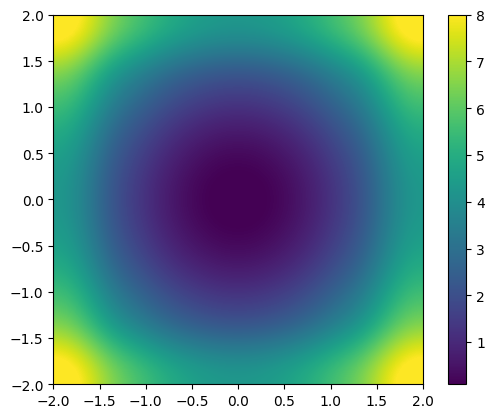

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

nx = 10
xlin = np.linspace(-2, 2, nx)
ylin = np.linspace(-2, 2, nx)
X, Y = np.meshgrid(xlin, ylin)
Z = X**2 + Y**2

plt.imshow(Z, extent=(-2, 2, -2, 2), origin="lower", interpolation="spline36")
plt.colorbar()
plt.show()